In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import os

import osmnx as ox
import networkx as nx

ox.settings.overpass_settings = f'[out:json][timeout:60][date:"2025-06-20T00:00:00Z"]'

In [5]:
import pickle
data_path = "../../data/mydata/"
with open(os.path.join(data_path,"network_porto/porto_edges_new_simplify.pkl"), 'rb') as f:
    edgeinfo = pickle.load(f)
with open(os.path.join(data_path,"network_porto/porto_nodes_new.pkl"), 'rb') as f:
    nodeinfo = pickle.load(f)

In [7]:
our_nodes = gpd.read_file(os.path.join(data_path,"network_porto/porto_nodes.shp"))
our_edges = gpd.read_file(os.path.join(data_path,"network_porto/porto_edges.shp"))

In [12]:
min_lat, min_lon, max_lat, max_lon = float('inf'), float('inf'), float('-inf'), float('-inf')
pad = 0.01  # Add a small padding to ensure we capture all nodes
for _, (lon, lat, _) in nodeinfo.items():
    min_lat = min(min_lat, lat)
    max_lat = max(max_lat, lat)
    min_lon = min(min_lon, lon)
    max_lon = max(max_lon, lon)

print(f"Bounding box: ({min_lat}, {min_lon}), ({max_lat}, {max_lon})")

bbox = (min_lon - pad, min_lat - pad, max_lon + pad, max_lat + pad)

Bounding box: (41.1406333, -8.6886988), (41.1858412, -8.5559061)


In [13]:
columns = ["geometry", "amenity"]

In [14]:
POI_MAPPING = {
    "restaurant" : "catering", # amenity
    "cafe" : "catering", # amenity
    "fast_food" : "catering", # amenity
    "pub" : "catering", # amenity
    "bar" : "catering", # amenity
    "biergarten" : "catering", # amenity
    
    "school" : "education", # amenity
    "college" : "education", # amenity
    "kindergarten" : "education", # amenity
    "university" : "education", # amenity

    "hospital" : "medical", # amenity
    "clinic" : "medical", # amenity
    "doctors" : "medical", # amenity

    "bus_station" : "transport", # amenity
    "taxi" : "transport", # amenity
    "bus_stop" : "transport", # highway
    "station" : "transport", # public_transport
    "subway_entrance" : "transport", # amenity
    "tram_stop" : "transport", # public_transport
    
    
    "parking" : "parking", # parking
    
    "shopping_centre" : "retail", # shop
    "mall" : "retail", # shop
    "supermarket" : "retail", # shop
    "convenience" : "retail", # shop
    "marketplace" : "retail", # shop
    
    
    "hairdresser" : "living", # shop
    "laundry" : "living", # shop
    "beauty" : "living", # shop
    
    "office" : "business", # office
    "commercial" : "business", # landuse
    "retail" : "business", # landuse
    
    "hotel" : "tourism", # tourism
    "hostel" : "tourism", # tourism
    "guest_house"      : "tourism",
    "museum"           : "tourism",
    "attraction"       : "tourism",
    "wine_cellar"      : "tourism",
    
    "castle"           : "heritage",
    "monument"         : "heritage",
    "memorial"         : "heritage",
    "ruins"            : "heritage",
    "church"           : "heritage",
    
    "park"             : "leisure",
    "stadium"          : "leisure",
    "sports_centre"    : "leisure",
    "marina"           : "leisure",
    "garden"           : "leisure",

    "place_of_worship" : "religion",
}

N_POI_GROUPS = len(set(POI_MAPPING.values()))
print(N_POI_GROUPS)

12


In [15]:
tags = {
    "amenity": [
        # catering
        "restaurant", "cafe", "fast_food", "pub", "bar", "biergarten",

        # education
        "school", "college", "kindergarten", "university",

        # medical
        "hospital", "clinic", "doctors",

        # transport
        "bus_station", "taxi",

        # parking
        "parking",

        # retail centers
        "marketplace",
        
        # religion
        "place_of_worship",
    ],
    
    "shop": [
        "supermarket", "convenience",
        "hairdresser", "laundry", "beauty",
    ],

    "highway": [
        "bus_stop",
    ],
    "railway": [
        "station",
        "subway_entrance",
        "tram_stop",  
    ],
    "tourism": [
        "attraction",
        "guest_house",
        "hostel",
        "hotel",
        "museum",
        "wine_cellar",
        "viewpoint",
    ],
    "historic": True,
    "leisure": [                 
        "park",
        "stadium",           
        "sports_centre",
        "marina",
    ],
    "office": True,

    "landuse": [
        "retail",
        "commercial",
    ],
}

gdf_tags = {}

for tag, value in tags.items():
    if value is True:
        # e.g. "office": True — query the whole key
        try:
            gdf_tag = ox.features_from_bbox(bbox=bbox, tags={tag: True})
            gdf_tags[(tag, "__all__")] = gdf_tag
            print(f"  ✓ {tag}=* ({len(gdf_tag)} features)")
        except Exception as e:
            print(f"  ✗ {tag}=* failed: {e}")

    elif isinstance(value, list):
        for v in value:
            try:
                gdf_tag = ox.features_from_bbox(bbox=bbox, tags={tag: v})
                gdf_tags[(tag, v)] = gdf_tag
                print(f"  ✓ {tag}={v} ({len(gdf_tag)} features)")
            except Exception as e:
                print(f"  ✗ {tag}={v} failed: {e}")

gdf_pois = pd.concat(gdf_tags.values()).drop_duplicates()

  ✓ amenity=restaurant (1225 features)
  ✓ amenity=cafe (746 features)
  ✓ amenity=fast_food (135 features)
  ✓ amenity=pub (53 features)
  ✓ amenity=bar (186 features)
  ✓ amenity=biergarten (3 features)
  ✓ amenity=school (256 features)
  ✓ amenity=college (11 features)
  ✓ amenity=kindergarten (95 features)
  ✓ amenity=university (48 features)
  ✓ amenity=hospital (21 features)
  ✓ amenity=clinic (90 features)
  ✓ amenity=doctors (11 features)
  ✓ amenity=bus_station (5 features)
  ✓ amenity=taxi (55 features)
  ✓ amenity=parking (2355 features)
  ✓ amenity=marketplace (28 features)
  ✓ amenity=place_of_worship (233 features)
  ✓ shop=supermarket (132 features)
  ✓ shop=convenience (111 features)
  ✓ shop=hairdresser (230 features)
  ✓ shop=laundry (79 features)
  ✓ shop=beauty (103 features)
  ✓ highway=bus_stop (1886 features)
  ✓ railway=station (48 features)
  ✓ railway=subway_entrance (68 features)
  ✓ railway=tram_stop (42 features)
  ✓ tourism=attraction (116 features)
  ✓ to

In [16]:
print(gdf_pois.index.names)

['element', 'id']


In [17]:
gdf_pois = gdf_pois.reset_index()

In [18]:
gdf_pois.head()

,element,id,geometry,name,amenity,website,addr:city,addr:housenumber,addr:postcode,addr:street,...,contact:street,name:cs,roof:height,room,association,name:sl,fuel:octane_98,fuel:HGV_diesel,fuel:diesel,fuel:octane_95
0,node,416885399,POINT (-8.59226 41.16077),Scala,restaurant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,417992583,POINT (-8.59177 41.16082),Vitória,restaurant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,418091554,POINT (-8.59751 41.15905),Barrigas,restaurant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,418198053,POINT (-8.59323 41.16626),Al Forno,restaurant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,418198057,POINT (-8.59829 41.16562),Cidade,restaurant,https://chcidadeporto.comportugal.com,Porto,524,4200-211,Rua de Costa Cabral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
gdf_pois_reduced = gdf_pois[gdf_pois.geometry.notnull()]
gdf_pois_reduced = gdf_pois_reduced.set_crs(epsg=4326, allow_override=True)

In [26]:
cols = ["element", "id", "geometry"]
tags_cols = []
for poi_cat in tags.keys():
    tags_cols.append(poi_cat)

cols.extend(tags_cols)
gdf_pois_reduced = gdf_pois_reduced[[c for c in cols if c in gdf_pois_reduced.columns]]

In [27]:
gdf_pois_reduced.head()

,element,id,geometry,amenity,shop,highway,railway,tourism,historic,leisure,office,landuse
0,node,416885399,POINT (-8.59226 41.16077),restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,417992583,POINT (-8.59177 41.16082),restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,418091554,POINT (-8.59751 41.15905),restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,418198053,POINT (-8.59323 41.16626),restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,418198057,POINT (-8.59829 41.16562),restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print(gdf_pois_reduced[cols].notna().sum())

element     10346
id          10346
geometry    10346
amenity      5599
shop          693
highway      1897
railway       166
tourism       778
historic      416
leisure       219
office        679
landuse        93
dtype: int64


In [36]:
gdf_pois_reduced['poi_type'] = gdf_pois_reduced[tags_cols].bfill(axis=1).iloc[:, 0]


In [37]:
clean_gdf_pois = gdf_pois_reduced[["element", "id", "geometry", "poi_type"]].copy()
clean_gdf_pois.head(2)

,element,id,geometry,poi_type
0,node,416885399,POINT (-8.59226 41.16077),restaurant
1,node,417992583,POINT (-8.59177 41.16082),restaurant


In [39]:
clean_gdf_pois["poi_group"] = clean_gdf_pois["poi_type"].map(POI_MAPPING)
clean_gdf_pois = clean_gdf_pois.dropna(subset=["poi_group"])
clean_gdf_pois.head()

,element,id,geometry,poi_type,poi_group
0,node,416885399,POINT (-8.59226 41.16077),restaurant,catering
1,node,417992583,POINT (-8.59177 41.16082),restaurant,catering
2,node,418091554,POINT (-8.59751 41.15905),restaurant,catering
3,node,418198053,POINT (-8.59323 41.16626),restaurant,catering
4,node,418198057,POINT (-8.59829 41.16562),restaurant,catering


In [49]:
gdf_edges = our_edges.to_crs(epsg=4326)
clean_gdf_pois = clean_gdf_pois.to_crs(epsg=4326)

In [50]:
minx, miny, maxx, maxy = gdf_pois.total_bounds
print(minx, miny, maxx, maxy)

-8.6990373 41.1254415 -8.5453461 41.1992083


In [51]:
clean_gdf_pois = clean_gdf_pois.cx[minx:maxx, miny:maxy]

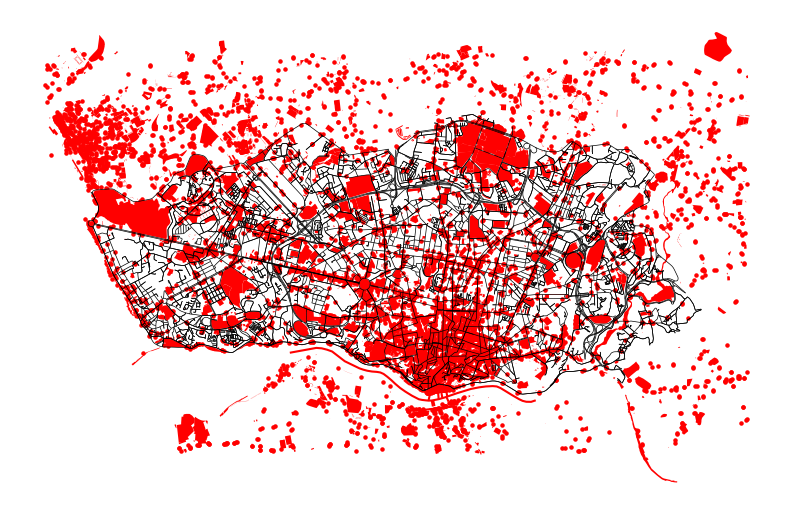

In [52]:
import matplotlib.pyplot as plt

fig, ax =plt.subplots(figsize=(10,10))

gdf_edges.plot(ax=ax, linewidth=0.5, color="black")
clean_gdf_pois.plot(ax=ax, color="red", markersize=5)
ax.axis("off")
plt.show()

In [53]:
BUFFER_METERS = 50

# reproject to a metric CRS for Porto
edge_buffered = gdf_edges.to_crs("EPSG:32629").copy()  # UTM zone 29N — correct for Porto
poi_projected = clean_gdf_pois.to_crs("EPSG:32629").copy()

edge_buffered["geometry"] = edge_buffered.geometry.buffer(BUFFER_METERS)

poi_to_segment = gpd.sjoin(
    poi_projected,
    edge_buffered[["osmid", "geometry"]],
    how="left",
    predicate="intersects",  # more robust than within
)

# check how many POIs got matched vs unmatched
n_total = len(poi_to_segment)
n_matched = poi_to_segment["osmid"].notna().sum()
n_unmatched = poi_to_segment["osmid"].isna().sum()
print(f"Matched:   {n_matched} / {n_total} ({100*n_matched/n_total:.1f}%)")
print(f"Unmatched: {n_unmatched} / {n_total} ({100*n_unmatched/n_total:.1f}%)")

Matched:   44019 / 47286 (93.1%)
Unmatched: 3267 / 47286 (6.9%)


In [54]:
print(clean_gdf_pois.poi_group.unique())

['catering' 'education' 'medical' 'transport' 'parking' 'retail'
 'religion' 'living' 'tourism' 'heritage' 'leisure' 'business']


In [55]:
poi_count = (
    poi_to_segment
    .groupby("osmid")
    .size()
    .reset_index(name="poi_count")
)

poi_group_pivot = (
    poi_to_segment
    .groupby(["osmid", "poi_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
poi_group_pivot.columns = ["osmid"] + [
    f"poi_{c}" for c in poi_group_pivot.columns[1:]
]

edge_with_poi = gdf_edges.merge(poi_count, on="osmid", how="left")
edge_with_poi = edge_with_poi.merge(poi_group_pivot, on="osmid", how="left")

# fill NaN for both count and all group columns
poi_cols = [c for c in edge_with_poi.columns if c.startswith("poi_")]
edge_with_poi[poi_cols] = edge_with_poi[poi_cols].fillna(0).astype(int)

# sanity checks
print(f"Edges total:          {len(edge_with_poi)}")
print(f"Edges with any POI:   {(edge_with_poi['poi_count'] > 0).sum()}")
print(f"Edges with no POI:    {(edge_with_poi['poi_count'] == 0).sum()}")
print(f"POI group columns:    {[c for c in poi_cols if c != 'poi_count']}")
print(f"\nPOI group totals:")
print(edge_with_poi[poi_cols].sum().sort_values(ascending=False).to_string())

Edges total:          10614
Edges with any POI:   8929
Edges with no POI:    1685
POI group columns:    ['poi_business', 'poi_catering', 'poi_education', 'poi_heritage', 'poi_leisure', 'poi_living', 'poi_medical', 'poi_parking', 'poi_religion', 'poi_retail', 'poi_tourism', 'poi_transport']

POI group totals:
poi_count        132593
poi_parking       43299
poi_transport     26893
poi_catering      21196
poi_education      9546
poi_leisure        7293
poi_tourism        5949
poi_religion       4221
poi_retail         3799
poi_living         3775
poi_medical        2359
poi_heritage       2248
poi_business       2015


In [58]:
import numpy as np
poi_group_cols = [c for c in edge_with_poi.columns if c.startswith("poi_") and c != "poi_count"]

# option A — log1p transform (recommended): compresses large counts, preserves zero
edge_with_poi[poi_group_cols] = np.log1p(edge_with_poi[poi_group_cols])

# sanity checks
print(f"Edges total:          {len(edge_with_poi)}")
print(f"Edges with any POI:   {(edge_with_poi['poi_count'] > 0).sum()}")
print(f"Edges with no POI:    {(edge_with_poi['poi_count'] == 0).sum()}")
print(f"POI group columns:    {[c for c in poi_cols if c != 'poi_count']}")
print(f"\nPOI group totals:")
print(edge_with_poi[poi_cols].sum().sort_values(ascending=False).to_string())


Edges total:          10614
Edges with any POI:   8929
Edges with no POI:    1685
POI group columns:    ['poi_business', 'poi_catering', 'poi_education', 'poi_heritage', 'poi_leisure', 'poi_living', 'poi_medical', 'poi_parking', 'poi_religion', 'poi_retail', 'poi_tourism', 'poi_transport']

POI group totals:
poi_count        132593.000000
poi_parking        8185.053007
poi_transport      7656.580798
poi_catering       5341.441157
poi_education      3823.654957
poi_leisure        2909.037826
poi_tourism        2043.431721
poi_retail         1759.154819
poi_religion       1714.855153
poi_living         1509.752789
poi_medical        1082.481812
poi_business        938.333711
poi_heritage        907.496329


In [62]:
sample_edge = gdf_edges.iloc[0]
print(sample_edge)

u                                                     25503936
v                                                   4722746638
key                                                          0
osmid                                                479127843
highway                                          motorway_link
lanes                                                        2
maxspeed                                                    70
oneway                                                       T
reversed                                                 False
length                                               32.388459
ref                                                       None
bridge                                                    None
name                                                      None
access                                                    None
width                                                     None
junction                                               

In [64]:
poi_lookup = {}
new_edgeinfo = {}
for _, row in edge_with_poi.iterrows():
    key = (str(row["u"]), str(row["v"]))
    poi_lookup[key] = [row[c] for c in poi_group_cols]

N_POI_GROUPS = len(poi_group_cols)

zero_vector = [0.0] * N_POI_GROUPS

for eid, edge in edgeinfo.items():
    u, v = edge[-2], edge[-1]
    poi_vector = poi_lookup.get((u, v), zero_vector)
    new_edgeinfo[eid] = edge + poi_vector

sample = next(iter(new_edgeinfo.items()))
print("Updated edge list: ", sample)
print("Expected length: ", 4 + N_POI_GROUPS)
print("Actual length: ", len(sample[1]))

Updated edge list:  (0, ['motorway_link', 32.3884588871153, '25503936', '4722746638', 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
Expected length:  16
Actual length:  16


In [66]:
sample = next(iter(new_edgeinfo.items()))
print("Full edge list  :", sample)
node_sample = next(iter(nodeinfo.items()))
print("Full node list  :", node_sample)

Full edge list  : (0, ['motorway_link', 32.3884588871153, '25503936', '4722746638', 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
Full node list  : ('25503936', (-8.6406364, 41.1660713, 3.0))


In [68]:
print(len(poi_group_cols))

for i, col in enumerate(poi_group_cols):
    print(f"POI group {i}: {col}")

12
POI group 0: poi_business
POI group 1: poi_catering
POI group 2: poi_education
POI group 3: poi_heritage
POI group 4: poi_leisure
POI group 5: poi_living
POI group 6: poi_medical
POI group 7: poi_parking
POI group 8: poi_religion
POI group 9: poi_retail
POI group 10: poi_tourism
POI group 11: poi_transport


In [69]:
import pandas as pd
import numpy as np

# extract poi columns from edgeinfo into a dataframe for easy analysis
records = []
for edge_idx, edge_list in new_edgeinfo.items():
    record = {"fid": edge_idx, "highway": edge_list[0], "length": edge_list[1]}
    for i, col in enumerate(poi_group_cols):
        record[col] = edge_list[4 + i]
    records.append(record)

df_edge_stats = pd.DataFrame(records)

print("=" * 60)
print("POI DISTRIBUTION ACROSS EDGES")
print("=" * 60)

print("\n--- Basic stats (log1p scale) ---")
print(df_edge_stats[poi_group_cols].describe().round(3).to_string())

print("\n--- Coverage: % edges with at least 1 POI per group ---")
coverage = (df_edge_stats[poi_group_cols] > 0).mean() * 100
print(coverage.sort_values(ascending=False).round(1).to_string())

print("\n--- Mean POI value by highway type ---")
print(
    df_edge_stats.groupby("highway")[poi_group_cols]
    .mean()
    .round(2)
    .sort_values("poi_catering", ascending=False)
    .to_string()
)

print("\n--- Correlation between POI groups ---")
corr = df_edge_stats[poi_group_cols].corr().round(2)
print(corr.to_string())

print("\n--- Top 10 edges by total POI richness ---")
df_edge_stats["poi_total"] = df_edge_stats[poi_group_cols].sum(axis=1)
top10 = (
    df_edge_stats.nlargest(10, "poi_total")
    [["fid", "highway", "length", "poi_total"] + poi_group_cols]
    .round(2)
)
print(top10.to_string())

print("\n--- Edges with zero POIs ---")
zero_mask = (df_edge_stats[poi_group_cols].sum(axis=1) == 0)
print(f"Count : {zero_mask.sum()} / {len(df_edge_stats)} ({100*zero_mask.mean():.1f}%)")
print(df_edge_stats[zero_mask]["highway"].value_counts().to_string())

POI DISTRIBUTION ACROSS EDGES

--- Basic stats (log1p scale) ---
       poi_business  poi_catering  poi_education  poi_heritage  poi_leisure  poi_living  poi_medical  poi_parking  poi_religion  poi_retail  poi_tourism  poi_transport
count     10614.000     10614.000      10614.000     10614.000    10614.000   10614.000    10614.000    10614.000     10614.000   10614.000    10614.000      10614.000
mean          0.088         0.503          0.361         0.085        0.275       0.142        0.102        0.771         0.162       0.166        0.193          0.721
std           0.328         0.871          0.643         0.332        0.571       0.436        0.348        1.092         0.454       0.433        0.537          0.906
min           0.000         0.000          0.000         0.000        0.000       0.000        0.000        0.000         0.000       0.000        0.000          0.000
25%           0.000         0.000          0.000         0.000        0.000       0.000        

In [70]:
with open(os.path.join(data_path,"network_porto/porto_edges_poi_new_simplify.pkl"), 'wb') as f:
    pickle.dump(edgeinfo, f)

In [ ]:
with open(os.path.join(data_path,"nwk_hcm/hcm_edges_poi_new_simplify.pkl"), 'rb') as f:
    edgeinfo = pickle.load(f)
    
sample_edge = iter(edgeinfo.values()).__next__()
print("Full edge list  :", sample_edge)
print("Total length    :", len(sample_edge))